# Text Classification

Oskar Jonsson
2000211138375

LLM Usage:

In [7]:
%pip install -q pandas matplotlib numpy torch importtools
%pip install -q transformers[sentencepiece] accelerate
%pip install -q scikit-learn
%pip install -q peft datasets
!pip install --upgrade peft


  Preparing metadata (setup.py) ... done


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import torch
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(torch.cuda.get_device_name(0))


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.10.0+cpu
CUDA available: False


AssertionError: Torch not compiled with CUDA enabled

In [16]:
class SentimentClassifier:
    def __init__(self, model_name="microsoft/deberta-v3-small", num_labels=2):
        """
        Initialize sentiment classifier with a pre-trained model and tokenizer.

        :param model_name: The name of the pre-trained model to use.
        :param num_labels: The number of labels for classification.
        """
        self.device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

        self.model = prepare_model_for_kbit_training(self.model)

        self.apply_lora()

        self.model.print_trainable_parameters()

        self.model = self.model.to(self.device)


    def apply_lora(self):
        """
        Apply LoRA (Low-Rank Adaptation) to the model for fine-tuning.
        """
        lora_config = LoraConfig(
            r=24,
            lora_alpha=32,
            target_modules=["query_proj", "key_proj", "value_proj", "dense"],
            modules_to_save=["classifier", "pooler.dense"],
            lora_dropout=0.1,
            bias="none",
            task_type="SEQ_CLS"
        )

        self.model = get_peft_model(self.model, lora_config)

    def load_data(self, path):
        """
        Load and preprocess dataset from txt file.

        :param path: The path to the dataset file.
        """

        texts = []
        labels = []

        with open(path, "r", encoding="utf8") as f:
            for line in f:

                label, text = line.strip().split("\t", 1)

                labels.append(int(label))
                texts.append(text)

        return pd.DataFrame({"text": texts, "label": labels})

    def tokenize(self, examples):
        """
        Tokenize the input texts using the tokenizer.

        :param examples: A batch of examples to tokenize.
        """

        return self.tokenizer(
            examples["text"],
            truncation=True,
            padding="max_length",
            max_length=512
        )


    def prepare_datasets(self, train_path, val_path, test_path):
        """
        Prepare datasets for training, validation, and testing.

        :param train_path: The path to the training dataset file.
        :param val_path: The path to the validation dataset file.
        :param test_path: The path to the testing dataset file.
        """

        train_df = self.load_data(train_path)
        val_df = self.load_data(val_path)
        test_df = self.load_data(test_path)

        train_df["label"] = train_df["label"].astype(int)
        val_df["label"] = val_df["label"].astype(int)
        test_df["label"] = test_df["label"].astype(int)


        print("Class distribution in training:")
        print(train_df['label'].value_counts())
        print("\nClass distribution in validation:")
        print(val_df['label'].value_counts())

        self.test_labels = test_df["label"]

        train_dataset = Dataset.from_pandas(train_df)
        val_dataset = Dataset.from_pandas(val_df)
        test_dataset = Dataset.from_pandas(test_df)

        train_dataset = train_dataset.map(self.tokenize, batched=True)
        val_dataset = val_dataset.map(self.tokenize, batched=True)
        test_dataset = test_dataset.map(self.tokenize, batched=True)

        train_dataset = train_dataset.rename_column("label", "labels")
        val_dataset = val_dataset.rename_column("label", "labels")
        test_dataset = test_dataset.rename_column("label", "labels")

        train_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
        val_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
        test_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

        return train_dataset, val_dataset, test_dataset

    def compute_metrics(self, eval_pred):
        """
        Compute accuracy metric for evaluation.

        :param eval_pred: The predictions and labels from the evaluation.
        """

        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)

        acc = accuracy_score(labels, preds)

        return {"accuracy": acc}


    def train(self, train_dataset, val_dataset):
        """
        Train the model using the Trainer API.

        :param train_dataset: The training dataset.
        :param val_dataset: The validation dataset.
        """

        training_args = TrainingArguments(
            output_dir="./results",
            learning_rate=3e-5,
            per_device_train_batch_size=8,
            per_device_eval_batch_size=8,
            num_train_epochs=5,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_steps=50,
            load_best_model_at_end=True,
            metric_for_best_model="accuracy",
            warmup_steps=100,
            optim="adamw_torch",
            gradient_accumulation_steps=4,
            weight_decay=0.01,
            fp16=False,
            bf16=True,
            max_grad_norm=0.5,
            report_to="none",
        )


        self.trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            processing_class=self.tokenizer,
            compute_metrics=self.compute_metrics,
            data_collator=DataCollatorWithPadding(self.tokenizer)
        )

        batch = train_dataset[0]

        batch = {k: v.unsqueeze(0).to(self.device) for k,v in batch.items()}

        outputs = self.model(**batch)

        print(outputs.loss)
        print(outputs.logits)


        self.trainer.train()
        self.trainer.save_model("/content/sentiment_model")
        self.tokenizer.save_pretrained("/content/sentiment_model")

    def evaluate(self, test_dataset):
        """
        Evaluate the model on the test dataset and print accuracy and classification report.

        :param test_dataset: The testing dataset.
        """

        preds = self.trainer.predict(test_dataset)

        y_pred = np.argmax(preds.predictions, axis=1)

        print("Accuracy:", accuracy_score(self.test_labels, y_pred))
        print(classification_report(self.test_labels, y_pred))




In [17]:
if __name__ == "__main__":

  classifier = SentimentClassifier()

  for name, param in classifier.model.named_parameters():
      if "classifier" in name or "pooler" in name:
          print(name, param.requires_grad)

  train_dataset, val_dataset, test_dataset = classifier.prepare_datasets(
      "ReviewBaseTraining.txt",
      "ReviewBaseValidation.txt",
      "ReviewBaseTest.txt"
  )

  print(train_dataset[0])

  classifier.train(train_dataset, val_dataset)

  classifier.evaluate(test_dataset)


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias       

trainable params: 2,582,786 || all params: 144,479,236 || trainable%: 1.7877
base_model.model.pooler.dense.original_module.weight False
base_model.model.pooler.dense.original_module.bias False
base_model.model.pooler.dense.modules_to_save.default.weight True
base_model.model.pooler.dense.modules_to_save.default.bias True
base_model.model.classifier.original_module.weight False
base_model.model.classifier.original_module.bias False
base_model.model.classifier.modules_to_save.default.weight True
base_model.model.classifier.modules_to_save.default.bias True
Class distribution in training:
label
0    5000
1    5000
Name: count, dtype: int64

Class distribution in validation:
label
0    2500
1    2500
Name: count, dtype: int64


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


{'labels': tensor(0), 'input_ids': tensor([ 5372,   265,   266,   642,   328,   303, 27961,  3582,   270,   266,
        11547,   323, 45903,   321,   275,   266,  1802,  1972,   272,   269,
          266,  8949,   738,   265, 14772,  5550,   323,   336,  3972, 13908,
         1976,   269,  1387,   352,   299, 10991,   366,  5791, 15744,   293,
          262,  3286, 25560,   268,   265,   278,   382,  1550, 14987,   323,
         3289,   278,  7213, 14772,   262, 58886,   326,   275,   363,  1042,
         5273,  2275,   570,   278,   348,   461,   442,  2237,   323,  1289,
          421,   292,   262,  3746,   403,   282,  1387,   442,   323,   279,
        37163,  5622,   338,   365, 10719,  1329,   639,   264,   266,   883,
        35336,   323,   589,   266,  2064,   674,   278,   382,  1550,   493,
          354,   274,   520,   428,   275,   347,   397, 38697,   293,   723,
          426, 32483, 15707,  2548, 41265, 18895,   323,  6230,  2906, 13309,
        42354,   263, 42012, 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.787442,0.206129,0.924600
2,0.631879,0.204934,0.933400
3,0.653345,0.195129,0.936800
4,0.667225,0.199509,0.935600
5,0.591931,0.192726,0.936400


Accuracy: 0.943
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2500
           1       0.96      0.93      0.94      2500

    accuracy                           0.94      5000
   macro avg       0.94      0.94      0.94      5000
weighted avg       0.94      0.94      0.94      5000



In [28]:
class NgramPerceptronClassifier:
    def __init__(self, ngram_ranges=[1,2,3], cmins=[1,3,10,100], max_iter=5000):
        """
        Linear perceptron classifier with n-gram features.

        :param ngram_ranges: List of nmax values to try (1=unigrams, 2=uni+bi, 3=uni+bi+tri).
        :param cmins: List of minimum instance counts for feature inclusion.
        :param max_iter: Maximum iterations for the LogisticRegression.
        """

        self.ngram_ranges = ngram_ranges
        self.cmins = cmins
        self.max_iter = max_iter
        self.best_models = {}

    def prepare_datasets(self, train_path, val_path, test_path):
        """
        Prepare datasets for training, validation, and testing.

        :param train_path: The path to the training dataset file.
        :param val_path: The path to the validation dataset file.
        :param test_path: The path to the testing dataset file.
        """

        def load_data(path):
            texts, labels = [], []
            with open(path, "r", encoding="utf8") as f:
                for line in f:
                    label, text = line.strip().split("\t", 1)
                    labels.append(int(label))
                    texts.append(text)
            return pd.DataFrame({"text": texts, "label": labels})

        train_df = load_data(train_path)
        val_df = load_data(val_path)
        test_df = load_data(test_path)

        print("Class distribution in training:")
        print(train_df['label'].value_counts())
        print("\nClass distribution in validation:")
        print(val_df['label'].value_counts())

        return train_df, val_df, test_df

    def fit(self, train_df, val_df):
        """
        Fit models on training data, selecting best model by validation accuracy.

        :param train_df: The training dataset.
        :param val_df: The validation dataset.
        """

        X_train, y_train = train_df['text'], train_df['label']
        X_val, y_val = val_df['text'], val_df['label']

        for n in self.ngram_ranges:
            best_acc = 0
            best_model = None
            best_vectorizer = None

            for cmin in self.cmins:
                vectorizer = CountVectorizer(ngram_range=(1, n), min_df=cmin)
                X_train_vec = vectorizer.fit_transform(X_train)
                X_val_vec = vectorizer.transform(X_val)

                clf = LogisticRegression(max_iter=self.max_iter, solver='saga')
                clf.fit(X_train_vec, y_train)

                val_pred = clf.predict(X_val_vec)
                acc = accuracy_score(y_val, val_pred)

                print(f"n={n}, cmin={cmin}, val_acc={acc:.4f}")

                if acc > best_acc:
                    best_acc = acc
                    best_model = clf
                    best_vectorizer = vectorizer

            self.best_models[n] = {
                'model': best_model,
                'vectorizer': best_vectorizer,
                'val_acc': best_acc
            }

    def evaluate(self, test_df):
        """
        Evaluate the best models on the test set.

        :param test_df: The testing dataset.
        :return: Dictionary with results per n-gram size.
        """

        X_test, y_test = test_df['text'], test_df['label']
        results = {}

        for n, data in self.best_models.items():
            model = data['model']
            vectorizer = data['vectorizer']

            X_test_vec = vectorizer.transform(X_test)
            y_pred = model.predict(X_test_vec)
            acc = accuracy_score(y_test, y_pred)

            print(f"n={n}, Test Accuracy={acc:.4f}")
            results[n] = {
                'test_acc': acc,
                'classification_report': classification_report(y_test, y_pred)
            }

        return results

    def visualize_review(self, review_text, n):
      """
      Visualize n-gram weights for a single review.

      :param review_text: Input review text.
      :param n: Which model to use (1, 2, or 3).
      """

      model = self.best_models[n]["model"]
      vectorizer = self.best_models[n]["vectorizer"]

      feature_names = vectorizer.get_feature_names_out()
      weights = model.coef_[0]

      feature_dict = dict(zip(feature_names, weights))

      tokens = review_text.split()

      ngrams = []
      for k in range(1, n+1):
          for i in range(len(tokens)-k+1):
              ngrams.append(" ".join(tokens[i:i+k]))

      values = []
      for ng in ngrams:
          values.append(feature_dict.get(ng, 0))

      colors = ["green" if v > 0 else "red" if v < 0 else "gray" for v in values]

      plt.figure(figsize=(10,6))
      plt.barh(range(len(ngrams)), values, color=colors)
      plt.yticks(range(len(ngrams)), ngrams)
      plt.xlabel("Weight")
      plt.title(f"{review_text}")
      plt.show()

    def compute_coverage_ratio(self, test_df):
      """
      Compute coverage ratio on the test set.
      """

      results = {}

      for n, data in self.best_models.items():

          vectorizer = data["vectorizer"]
          vocab = set(vectorizer.get_feature_names_out())

          total = 0
          covered = 0

          for text in test_df["text"]:

              tokens = text.split()

              ngrams = []
              for k in range(1, n+1):
                  for i in range(len(tokens)-k+1):
                      ngrams.append(" ".join(tokens[i:i+k]))

              total += len(ngrams)

              for ng in ngrams:
                  if ng in vocab:
                      covered += 1

          coverage = covered / total
          results[n] = coverage

          print(f"n={n}, coverage ratio={coverage:.4f}")

      return results




Class distribution in training:
label
0    5000
1    5000
Name: count, dtype: int64

Class distribution in validation:
label
0    2500
1    2500
Name: count, dtype: int64
n=1, cmin=1, val_acc=0.8552
n=1, cmin=3, val_acc=0.8558
n=1, cmin=10, val_acc=0.8542
n=1, cmin=100, val_acc=0.8498
n=2, cmin=1, val_acc=0.8648
n=2, cmin=3, val_acc=0.8644
n=2, cmin=10, val_acc=0.8638
n=2, cmin=100, val_acc=0.8528
n=3, cmin=1, val_acc=0.8690
n=3, cmin=3, val_acc=0.8652
n=3, cmin=10, val_acc=0.8636
n=3, cmin=100, val_acc=0.8564
n=1, Test Accuracy=0.8714
n=2, Test Accuracy=0.8868
n=3, Test Accuracy=0.8852

=== n=1 ===
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      2500
           1       0.88      0.86      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000


=== n=2 ===
              precision    recall  f1-score   support

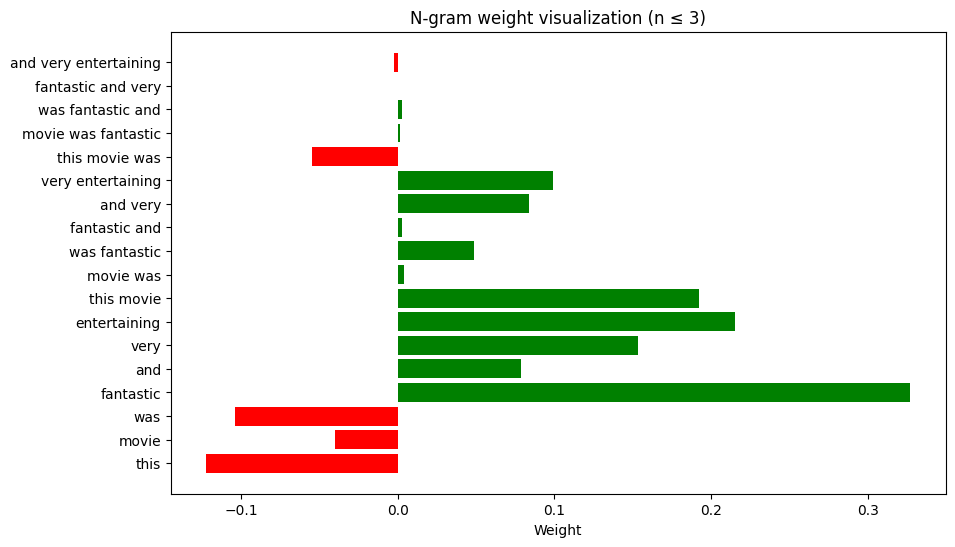

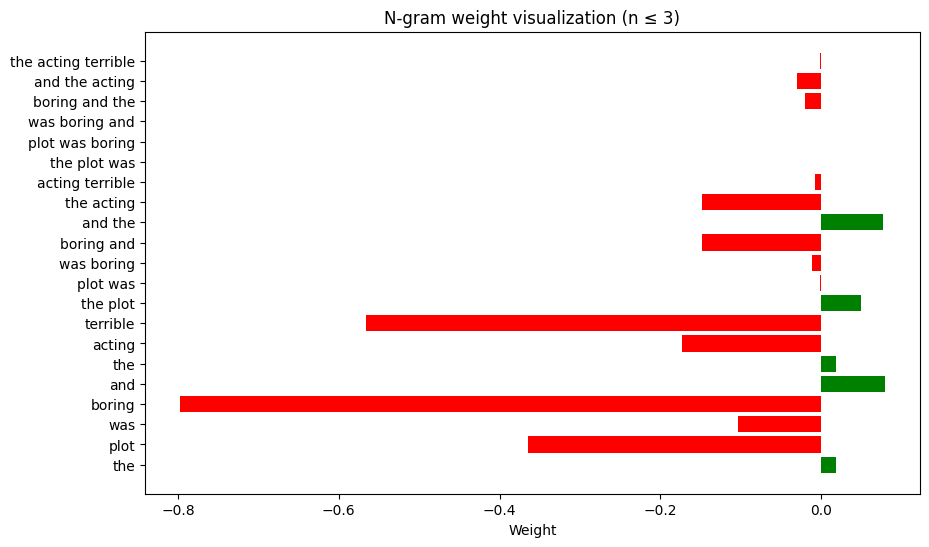

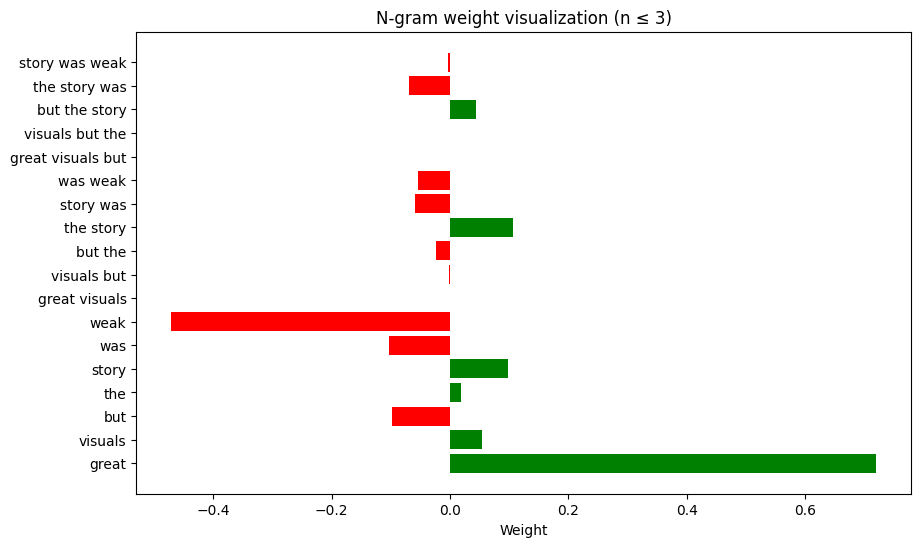

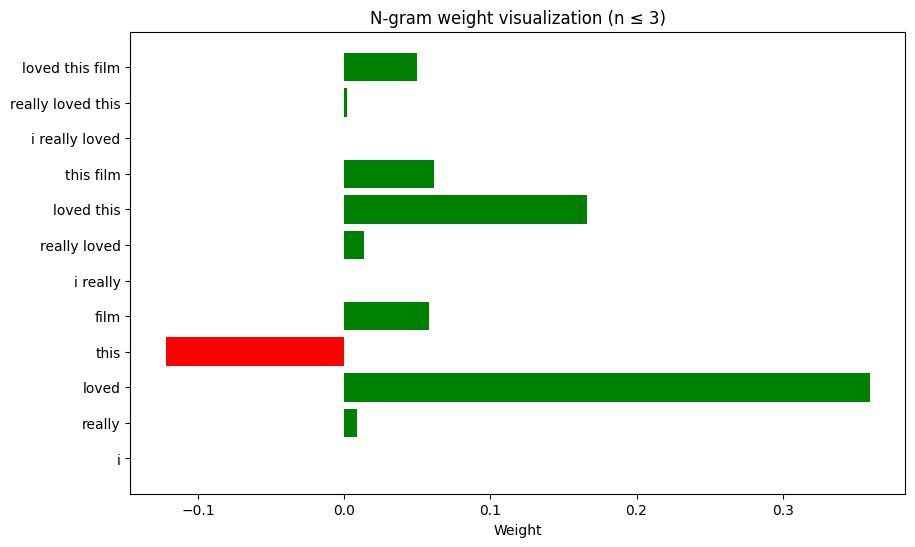

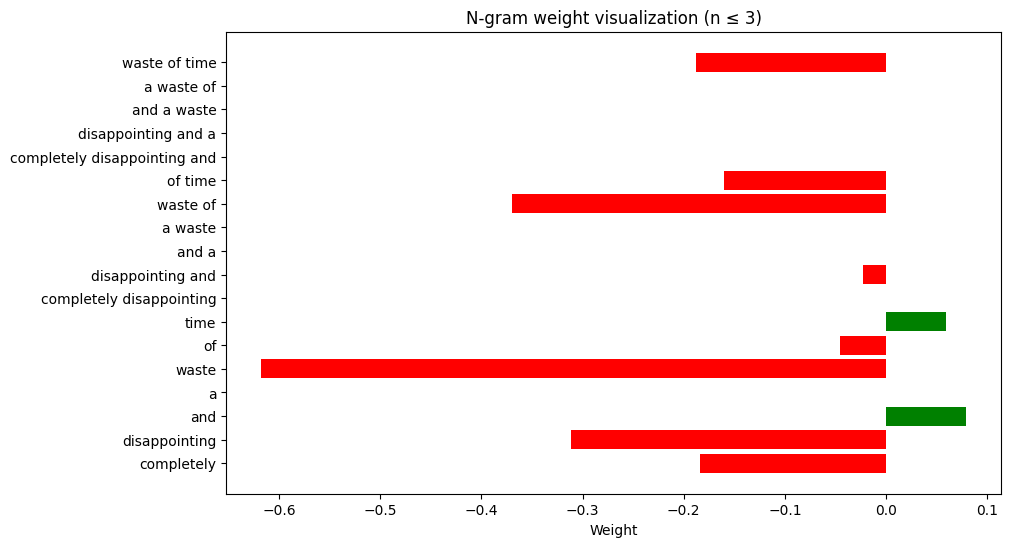

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ngram_models.pkl'

In [11]:
if __name__ == "__main__":
    ngram_clf = NgramPerceptronClassifier(ngram_ranges=[1,2,3], cmins=[1,3,10,100])

    train_df, val_df, test_df = ngram_clf.prepare_datasets(
      "ReviewBaseTraining.txt",
      "ReviewBaseValidation.txt",
      "ReviewBaseTest.txt"
    )

    ngram_clf.fit(train_df, val_df)

    results = ngram_clf.evaluate(test_df)

    for n, data in results.items():
      print(f"\n=== n={n} ===")
      print(data['classification_report'])

    ngram_clf.compute_coverage_ratio(test_df)

    reviews = [
        "this movie was fantastic and very entertaining",
        "the plot was boring and the acting terrible",
        "great visuals but the story was weak",
        "i really loved this film",
        "completely disappointing and a waste of time"
    ]

    for r in reviews:
        ngram_clf.visualize_review(r, n=3)


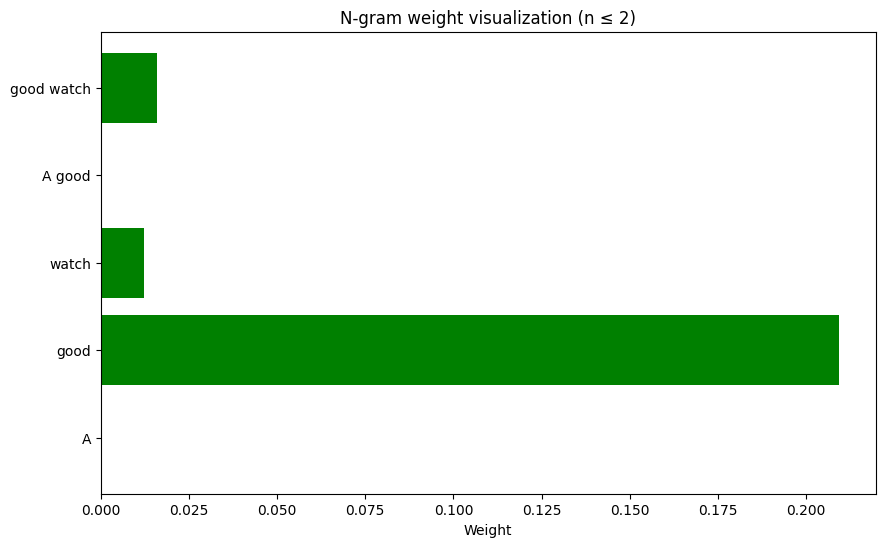

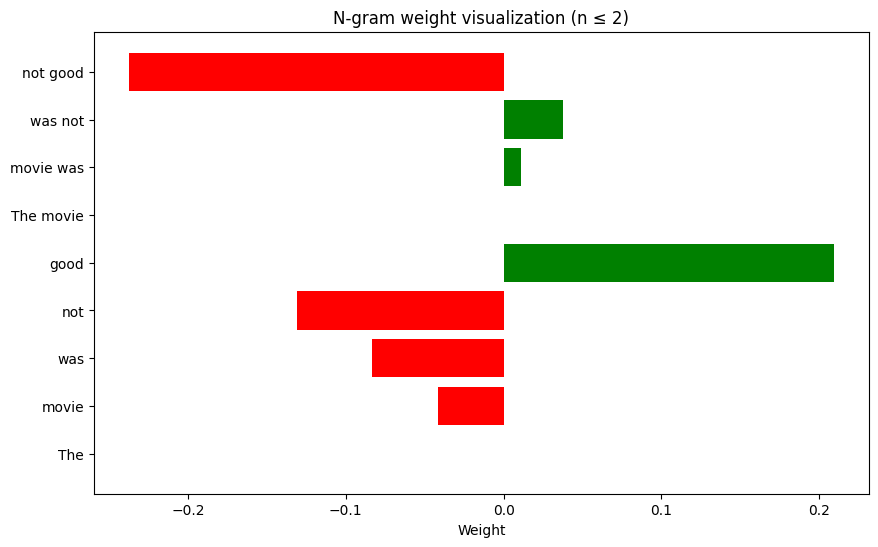

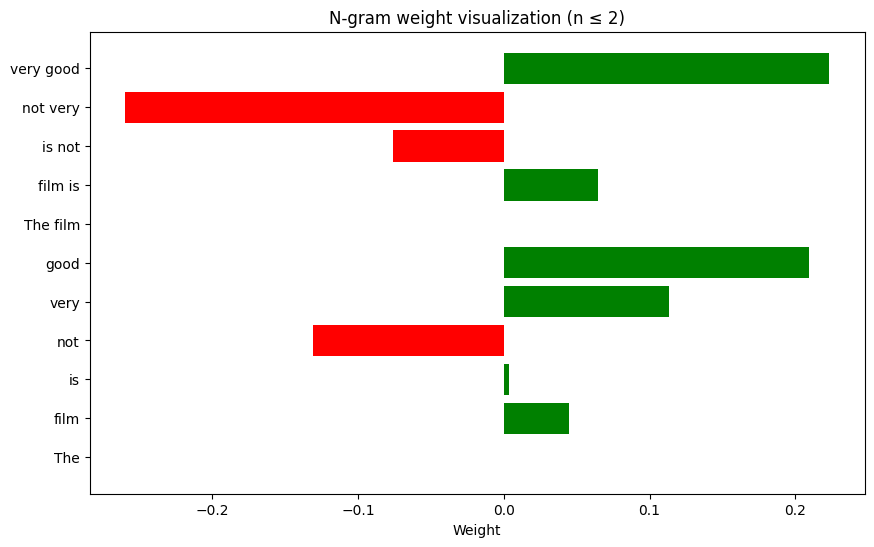

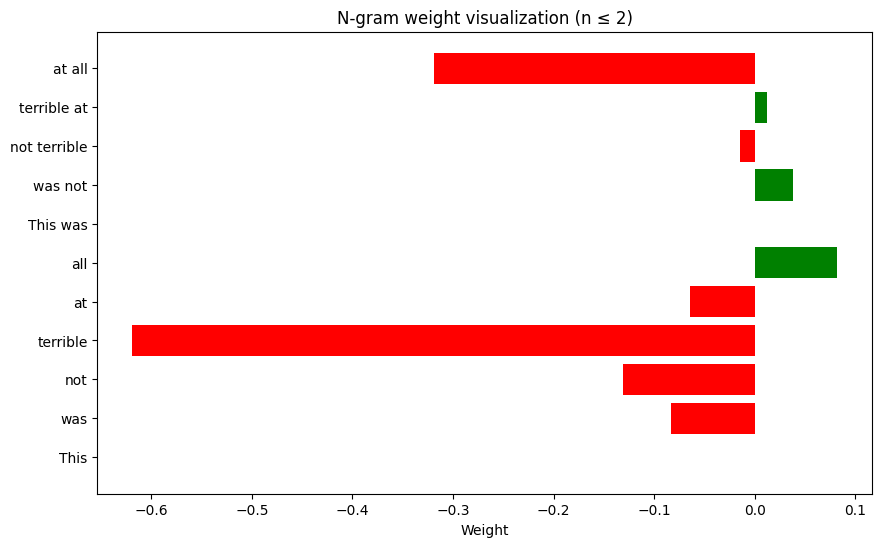

In [33]:
reviews = [
        "A good watch",
        "The movie was not good",
        "The film is not very good",
        "This was not terrible at all"
    ]
for r in reviews:
    ngram_clf.visualize_review(r, n=2)

n = 1 means unigrams where only single words are used as features, absolutley no context is used in the bias weight. Words like "strong" has a positive bias even if it is used in a negative context for example.

n = 2 means unigrams and bigrams so we use single words and paris of consecutive words. Patterns like "not good" therefore becomes negative.

n = 3 uses unigrams, bigrams and trigrams so it uses three-word sequences which is even more context. However, trigrams are rarer compared to bigrams so even though more context is used in predictions, the accuracy is almost the same. for n = 1 to n = 2 we see clear improvement due to bigrams often giving more useful context.

The covergae decreases since longer phrases appear less frequently and many test phrases are therefore not even seen in the training.

The perceptron approach is however very interpretable since each word and n combinations of subsequent words are given a bias. DeBERTa-v3 is not interpretable but its accuracy is higher. It understands the context and language struxture better as the perceptron approach is limited by our n parameter. BERT already knows thinggs like synonyms and idioms as it is trained on a HUGE dataset already before we fine-tune it. Perceptron therefore relies on exact phrases seen in the training set and can only use these when making predictions as seen in the low coverage ratios.

Transformers represents words as vectors in semantic space which relates similar words to eachother and therefore gives them similar bias.